In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

In [9]:
df = pd.read_csv('oasis_longitudinal.csv')

# Selección de atributos clínicos según informe_2.pdf [4, 6]
features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features]
y = df['CDR'].astype(str) # 4 clases: 0.0, 0.5, 1.0, 2.0

# Imputación de datos faltantes (SES y MMSE) usando la mediana [7]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Listas para almacenar métricas de las 10 iteraciones [8]
metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}


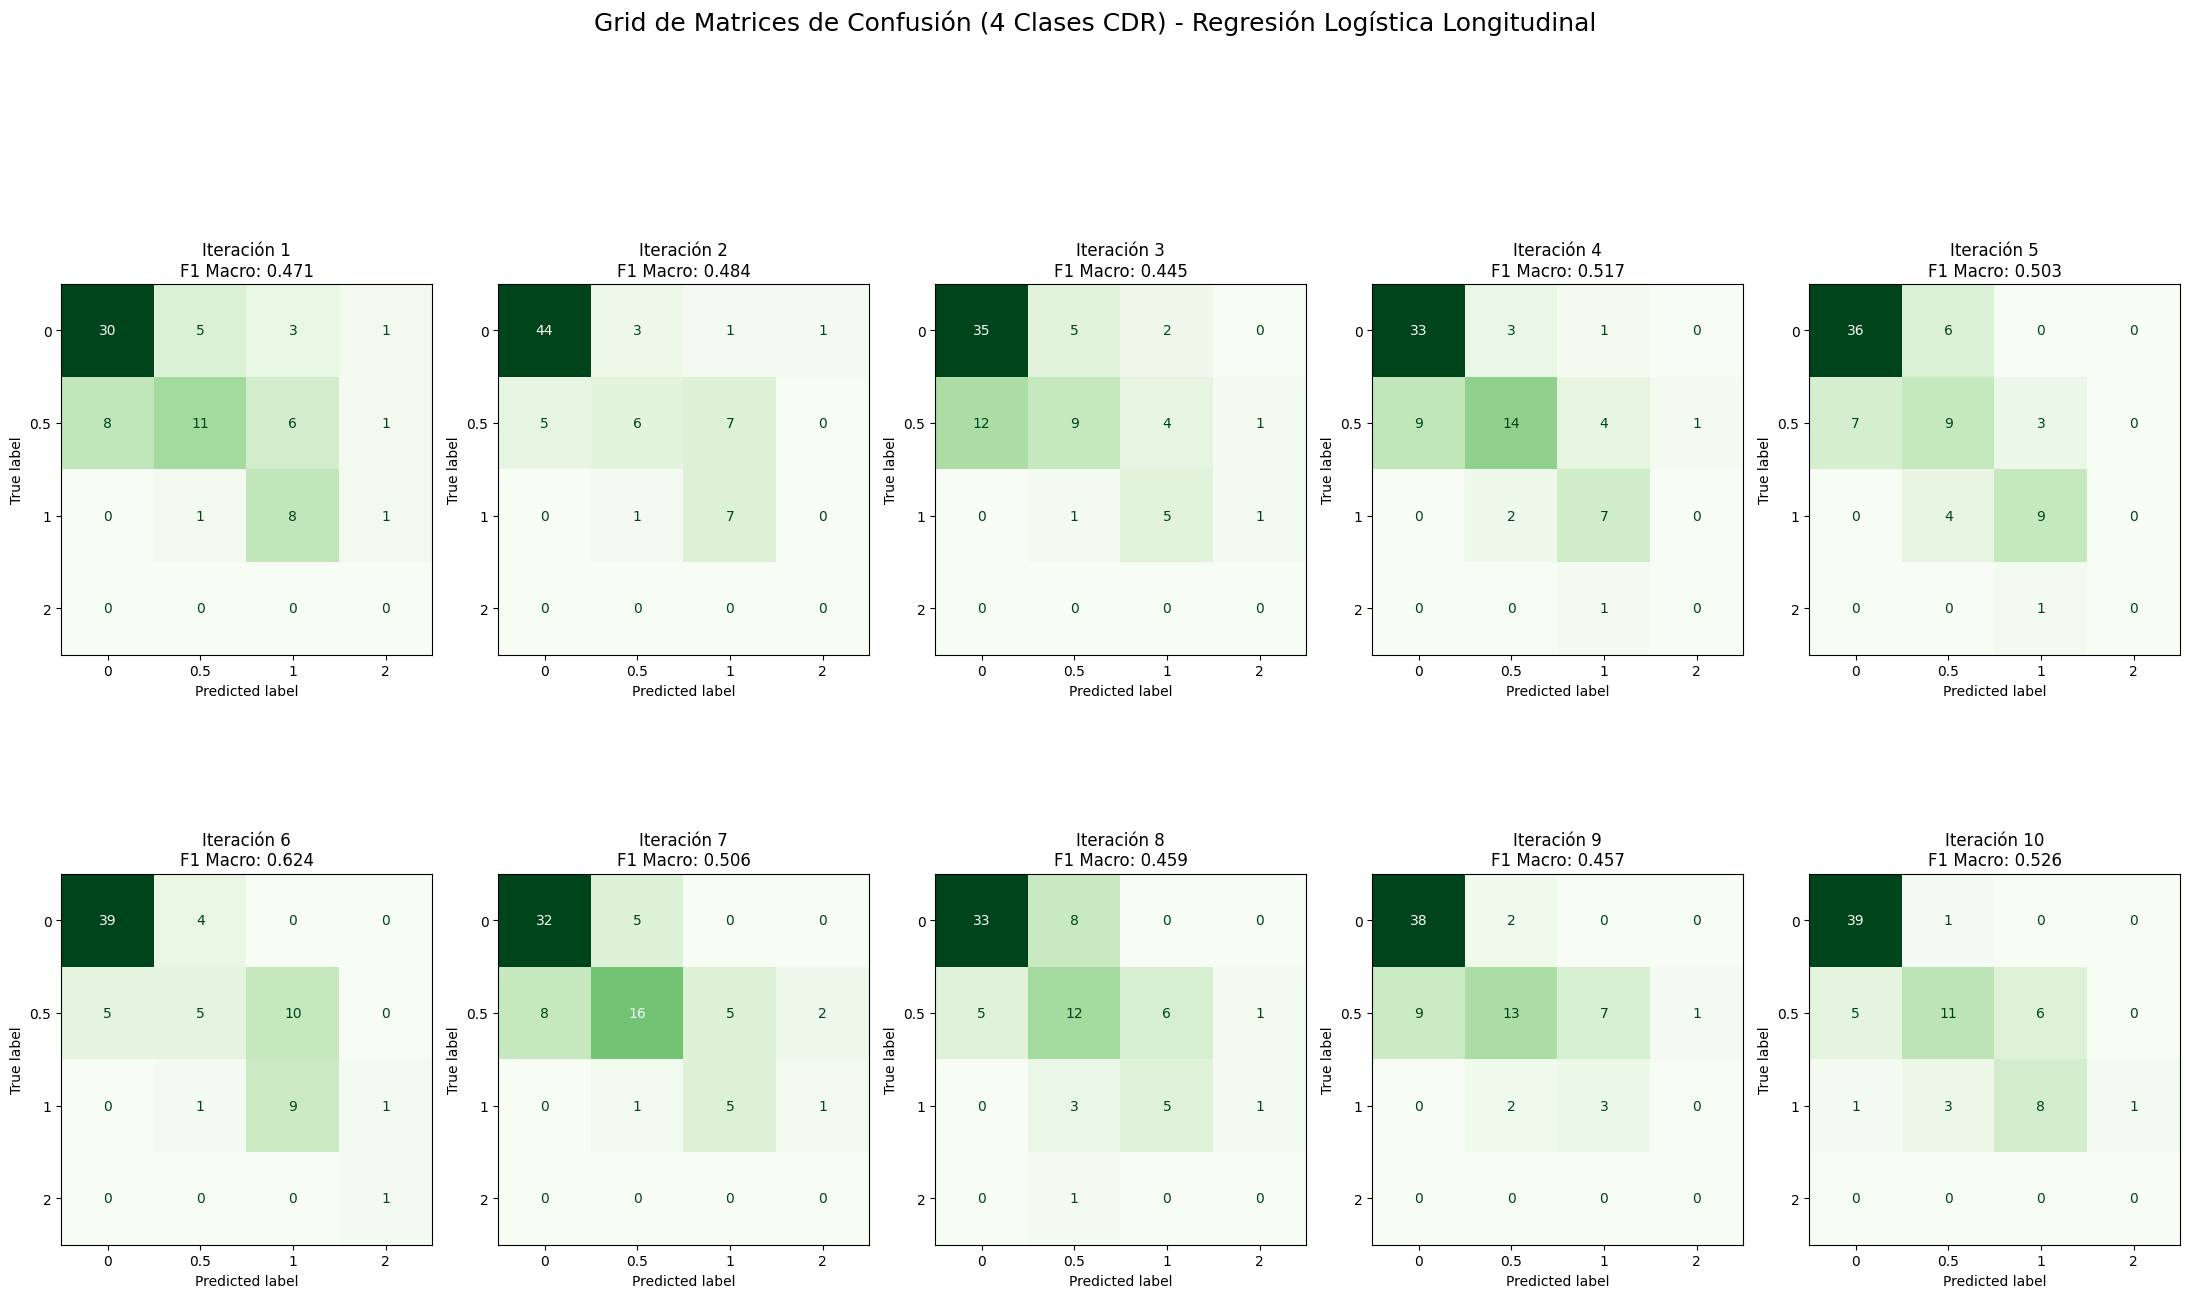

In [12]:
# Configuración del grid para las 10 matrices de confusión (2 filas x 5 columnas)
fig, axes = plt.subplots(2, 5, figsize=(22, 15))
axes = axes.flatten()

# 2. Diseño Experimental: 10 Validaciones Independientes 80/20 [1]
for i in range(10):
    # Partición aleatoria única por iteración
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=i
    )
    
    # 3. Escalamiento: Requisito crítico para Regresión Logística [7]
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración [6]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 4. Entrenamiento del Modelo de Regresión Logística
    # Se omite 'multi_class' por compatibilidad con versiones recientes de scikit-learn
    # class_weight='balanced' para compensar el desbalance de la clase CDR 2.0 [8, 9]
    lr = LogisticRegression(solver='lbfgs', 
                            max_iter=1000, 
                            class_weight='balanced', 
                            random_state=42)
    lr.fit(X_train_s, y_train)
    y_pred = lr.predict(X_test_s)
    
    # 5. Registro de Métricas (Promedio Macro obligatorio para desbalance) [9]
    metrics['acc'].append(accuracy_score(y_test, y_pred))
    metrics['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    metrics['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    metrics['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    # 6. Generación de la Matriz de Confusión para la iteración [10]
    cm = confusion_matrix(y_test, y_pred, labels=['0.0', '0.5', '1.0', '2.0'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    
    # Dibujo en el grid
    disp.plot(ax=axes[i], cmap='Greens', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1 Macro: {metrics['f1'][-1]:.3f}")

plt.suptitle("Grid de Matrices de Confusión (4 Clases CDR) - Regresión Logística Longitudinal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [11]:
print("\n--- DESEMPEÑO FINAL REGRESIÓN LOGÍSTICA (Promedio de 10 Iteraciones) ---")
print(f"Accuracy:  {np.mean(metrics['acc']):.4f} ± {np.std(metrics['acc']):.4f}")
print(f"Precision: {np.mean(metrics['prec']):.4f} ± {np.std(metrics['prec']):.4f}")
print(f"Recall:    {np.mean(metrics['rec']):.4f} ± {np.std(metrics['rec']):.4f}")
print(f"F1-Score:  {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")


--- DESEMPEÑO FINAL REGRESIÓN LOGÍSTICA (Promedio de 10 Iteraciones) ---
Accuracy:  0.7093 ± 0.0390
Precision: 0.4998 ± 0.0404
Recall:    0.5297 ± 0.0749
F1-Score:  0.4992 ± 0.0491
